# Sobre árboles de decisión

Comenzaremos revisando algunos conceptos básicos sobre el funcionamiento de los árboles de decisión. A medida que avancemos en las clases, exploraremos sus diversas características y desafíos, con el objetivo de comprender por qué, en problemas de modelado de datos tabulares, siguen siendo el estado del arte, superando incluso a los modelos más complejos de redes neuronales.



Recomendamos chusmear esta hermosa visualización de cómo funciona un árbol de decisión.

[Cómo funciona un árbol de decisión](http://www.r2d3.us/visual-intro-to-machine-learning-part-1/)

Y luego empezaremos a trabajar con nuestro conjunto de datos para *tratar* de modelar uno. Para eso, debemos iniciar el entorno

## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree,  _tree


Variables importantes

In [ ]:
import os, sys

EN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
if EN_COLAB:
    dataset_path = "/content/drive/MyDrive/DMEyF/2026/notebooks/data/"
else:
    raiz = os.getcwd()
    for _ in range(4):
        if os.path.isdir(os.path.join(raiz, "data")) or os.path.isdir(os.path.join(raiz, ".git")):
            break
        raiz = os.path.dirname(raiz)
    dataset_path = os.path.join(raiz, "data") + os.sep

dataset_file = 'competencia_01.csv'

ganancia_acierto = 1_072_500
costo_estimulo = 27_500

Cargamos el **dataset**, vamos a trabajar en esta ocasión solo con un periodo: **202104**.

Algo que va a generar algo de confusión es que no separemos con **Train / Test** en esta ocasión.

**NO ENTRE EN PÁNICO**, en esta cursada se le dedicará mucho tiempo a entender y combatir el problema del overfitting. Pero no hoy.

In [4]:
data = pd.read_csv(dataset_path+dataset_file)
data = data[data['foto_mes'] == 202104]

X = data.drop('clase_ternaria', axis=1)
y = data['clase_ternaria']


Veamos que porcentaje ocupa de nuestro dataset, el target que queremos predecir

In [5]:
data['clase_ternaria'].value_counts(normalize=True)*100

clase_ternaria
CONTINUA    98.716347
BAJA+2       0.697558
BAJA+1       0.586095
Name: proportion, dtype: float64

* **¿Había trabajado con un target tan poco representativo?**
* **¿Cree que esto es algo común o tan solo una rareza?**

## Primer árbol
Con nuestros datos ya cargados en **memoria**, podemos dedicarnos a generar nuestro primer árbol

### Párametros

(gentileza de chat-gpt en un 90%)

El **DecisionTreeClassifier** en scikit-learn tiene varios parámetros que controlan cómo se construye el árbol de decisión. A continuación te explico los más importantes:

1. **criterion**: Este parámetro define la función que se usa para medir la calidad de una división (split). Las opciones principales son:

    * **gini** (predeterminado): Utiliza el índice de Gini, que mide la impureza de las particiones. Un valor de Gini más bajo significa que una partición es más pura.
    * **entropy**: Utiliza la entropía de la información, relacionada con el concepto de ganancia de información. Se enfoca en reducir la incertidumbre en las particiones.

2. **max_depth**: Controla la profundidad máxima del árbol.

3. **min_samples_split**: Especifica el número mínimo de muestras que un nodo debe tener para poder dividirse.

4. **min_samples_leaf**: Define el número mínimo de muestras que debe tener una hoja (nodo final).

5. **max_features**: Indica el número máximo de características que el modelo debe considerar para hacer la mejor división.

6. **max_leaf_nodes**: Especifica el número máximo de nodos hoja que el árbol puede tener.

7. **random_state**: Fija la semilla utilizada por el generador de números aleatorios, lo que garantiza que los resultados del entrenamiento sean reproducibles.

8. **ccp_alpha**: Parámetro de complejidad de poda mínima, utilizado para la poda de árboles de decisión después de que se hayan construido. Un valor más alto lleva a árboles más pequeños.

 **EN LA CURSADA CREEMOS QUE LA INTELIGENCIA DEL ALUMNO CORRELACIONA DE FORMA NEGATIVA A VALOR QUE SETEA ESTE PARÁMETRO**

Queda de tarea para el alumnado jugar con algunas parametrías. Usaremos a continuación una simple

### Modelo

In [6]:
model = DecisionTreeClassifier(criterion='gini',
                               random_state=17,
                               min_samples_split=80,
                               min_samples_leaf=1,
                               max_depth=5)

model.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",80
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",17
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples i

### Visualización

Todo es mucho más bonito si tiene colores

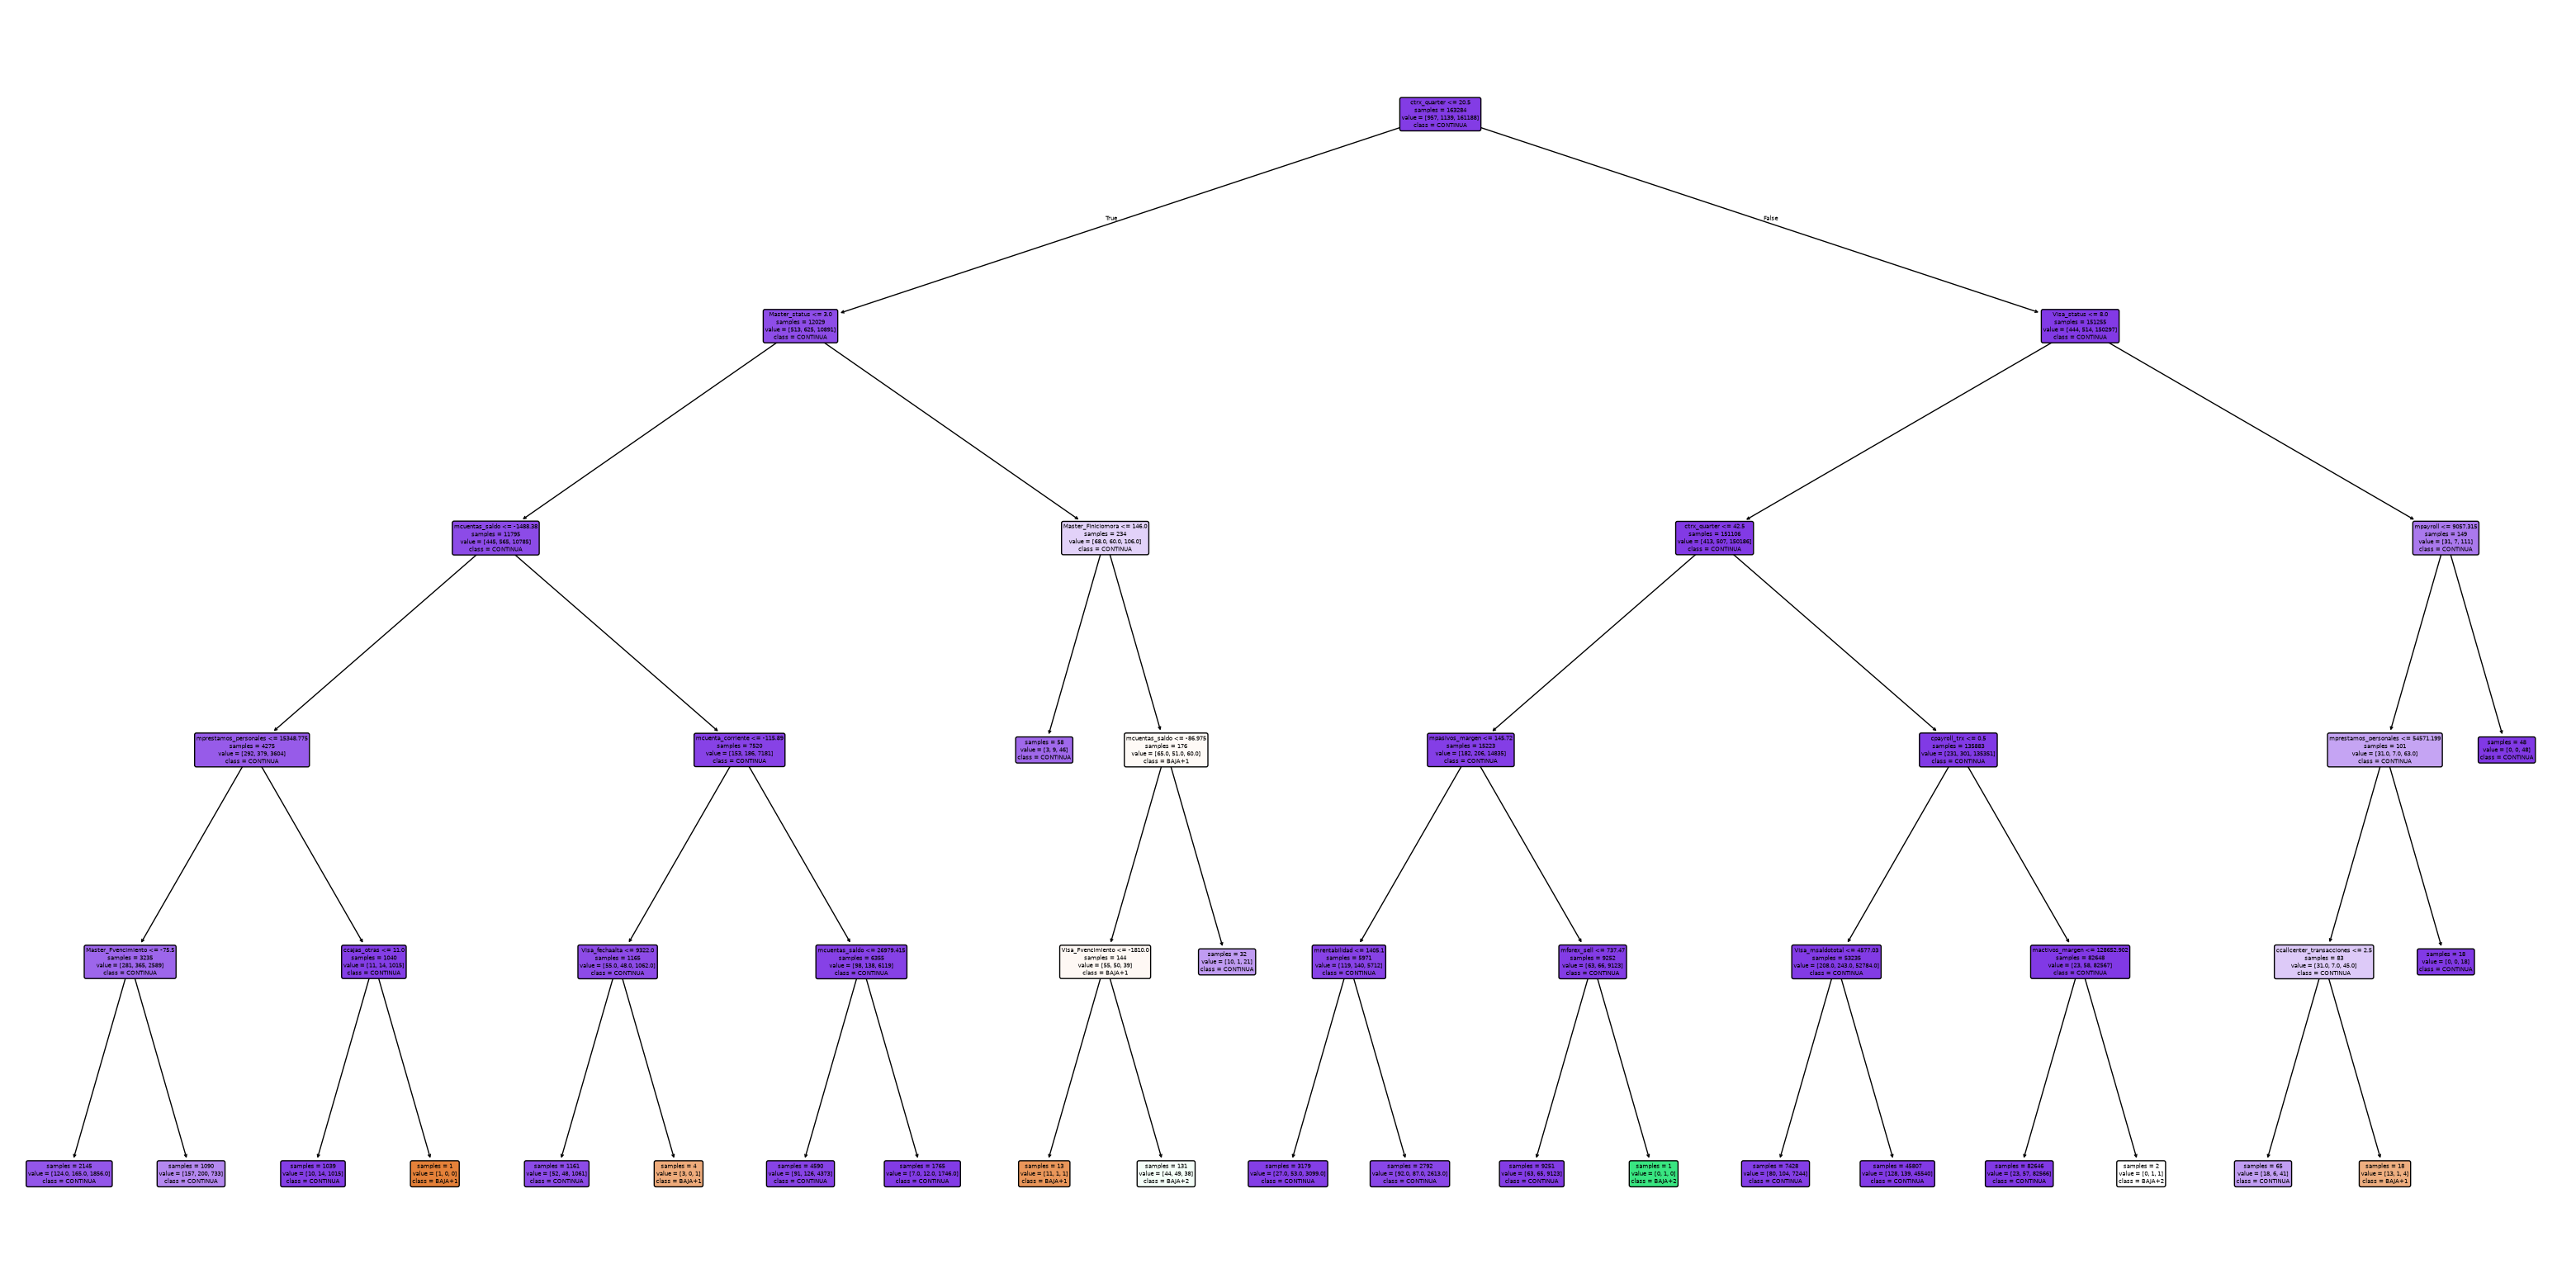

In [7]:
plt.figure(figsize=(40,20))
plot_tree(model, feature_names=X.columns, filled=True, class_names=model.classes_, rounded=True, impurity=False) #,  proportion=True)
plt.show()

### Midiendo el modelo

Mirando tan solo la visualización

* **¿Qué tan bien performó el modelo?**
* **¿Qué tan bien detectó los CONTINUA?**
* **¿Qué tan bien detectó los BAJA+2?**

Para meter manos en la masa, vamos a llevar las hojas del modelo a una tabla, para esto haremos uso de una función auxiliar

In [16]:
def get_leaf_info(tree):
    tree_ = tree.tree_
    class_names = tree.classes_
    leaf_info = []
    for i in range(tree_.node_count):
        if tree_.children_left[i] == _tree.TREE_LEAF:
            class_counts = tree_.value[i][0] * int(tree_.n_node_samples[i])
            predicted_class_index = class_counts.argmax()
            predicted_class = class_names[predicted_class_index]
            row = {
                'Node': i,
                'Samples': int(tree_.n_node_samples[i]),
                'Predicted Class': predicted_class
            }
            for j, class_name in enumerate(class_names):
                row[class_name] = int(class_counts[j])
            leaf_info.append(row)
    return pd.DataFrame(leaf_info)

leaf_df = get_leaf_info(model)
leaf_df


,Node,Samples,Predicted Class,BAJA+1,BAJA+2,CONTINUA
0,5,2145,CONTINUA,124,165,1856
1,6,1090,CONTINUA,157,200,733
2,8,1039,CONTINUA,10,14,1015
3,9,1,BAJA+1,1,0,0
4,12,1161,CONTINUA,52,48,1061
5,13,4,BAJA+1,3,0,1
6,15,4590,CONTINUA,91,126,4373
7,16,1765,CONTINUA,7,12,1746
8,18,58,CONTINUA,3,9,46
9,21,13,BAJA+1,11,1,1


Ahora en el dataset **leaf_ds** tenemos cada nodo terminal (hoja).

Vemos que según el modelo, no deberíamos mandar ningún estímulo, dado que no detectó ningún **BAJA+2**. Sin embargo dudaremos de esto y veremos cuanta plata nos hubiera dejado cada hoja, si enviáramos a los clientes que cayeron en esta.


In [9]:
leaf_df["ganancia"] = ganancia_acierto*leaf_df["BAJA+2"] - costo_estimulo*leaf_df["BAJA+1"] + -costo_estimulo*leaf_df["CONTINUA"]
leaf_df.sort_values("ganancia", ascending=False, inplace=True)
leaf_df

,Node,Samples,Predicted Class,BAJA+1,BAJA+2,CONTINUA,ganancia
1,6,1090,CONTINUA,157,200,733,190025000
0,5,2145,CONTINUA,124,165,1856,122512500
10,22,131,BAJA+2,44,49,38,50297500
4,12,1161,CONTINUA,52,48,1061,20872500
13,29,2792,CONTINUA,91,87,2613,18947500
6,15,4590,CONTINUA,91,126,4373,12375000
8,18,58,CONTINUA,3,9,46,8305000
20,43,65,CONTINUA,18,6,41,4812500
15,32,1,BAJA+2,0,1,0,1072500
19,39,2,BAJA+2,0,1,1,1045000


Vaya! no son pocos las hojas que hubieran dado ganancia positiva, y todas a su vez estuvieron mal clasificadas por el modelo.

Veamos de calcular la probabilidad de **BAJA+2** por cada hoja

In [10]:
leaf_df["prob_baja_2"] = leaf_df["BAJA+2"]/leaf_df["Samples"]
leaf_df.sort_values("prob_baja_2", ascending=False, inplace=True)
leaf_df

,Node,Samples,Predicted Class,BAJA+1,BAJA+2,CONTINUA,ganancia,prob_baja_2
15,32,1,BAJA+2,0,1,0,1072500,1.000000
19,39,2,BAJA+2,0,1,1,1045000,0.500000
10,22,131,BAJA+2,44,49,38,50297500,0.374046
1,6,1090,CONTINUA,157,200,733,190025000,0.183486
8,18,58,CONTINUA,3,9,46,8305000,0.155172
20,43,65,CONTINUA,18,6,41,4812500,0.092308
0,5,2145,CONTINUA,124,165,1856,122512500,0.076923
9,21,13,BAJA+1,11,1,1,742500,0.076923
21,44,18,BAJA+1,13,1,4,605000,0.055556
4,12,1161,CONTINUA,52,48,1061,20872500,0.041344




Finalmente calculemos la ganancia acumulada para cada posible punto de corte:

In [11]:
leaf_df['gan_acumulada'] = leaf_df['ganancia'].cumsum()
leaf_df

,Node,Samples,Predicted Class,BAJA+1,BAJA+2,CONTINUA,ganancia,prob_baja_2,gan_acumulada
15,32,1,BAJA+2,0,1,0,1072500,1.000000,1072500
19,39,2,BAJA+2,0,1,1,1045000,0.500000,2117500
10,22,131,BAJA+2,44,49,38,50297500,0.374046,52415000
1,6,1090,CONTINUA,157,200,733,190025000,0.183486,242440000
8,18,58,CONTINUA,3,9,46,8305000,0.155172,250745000
20,43,65,CONTINUA,18,6,41,4812500,0.092308,255557500
0,5,2145,CONTINUA,124,165,1856,122512500,0.076923,378070000
9,21,13,BAJA+1,11,1,1,742500,0.076923,378812500
21,44,18,BAJA+1,13,1,4,605000,0.055556,379417500
4,12,1161,CONTINUA,52,48,1061,20872500,0.041344,400290000


* **¿Cuál es la ganancia máxima que puede obtener con este modelo?**
* **¿Nota alguna relación con la probabilidad de corte óptima discutida en la clase anterior?**


### Matrices de Confusión

Todos ya sabemos que es son las matrices de confusión y como usando los valores de la misma, podemos  [calcular varios estadísticos](https://en.wikipedia.org/wiki/Confusion_matrix#Table_of_confusion)

Una diferencia a lo trabajado hasta ahora en la maestría, es que por cada modelo no vamos a generar 1 matriz de confusión, sino múltiples, 1 por cada punto de corte.

Para eso tenemos que proceder:
* Agrupar los buenos y los malos, ya que la mayoría de los indicadores son binarios
* Calcular los valores: **TP, TN, FP y FN**

In [12]:
leaf_df["evento"] = leaf_df["BAJA+2"]
leaf_df["no_evento"] = leaf_df["CONTINUA"] + leaf_df["BAJA+1"]

leaf_df["evento_acum"] = leaf_df["evento"].cumsum()
leaf_df["no_evento_acum"] = leaf_df["no_evento"].cumsum()

total_evento = leaf_df["evento"].sum()
total_noevento = leaf_df["no_evento"].sum()

leaf_df['evento_restantes'] = total_evento - leaf_df["evento_acum"]
leaf_df['noevento_restantes'] = total_noevento - leaf_df["no_evento_acum"]

leaf_df["TP"] = leaf_df["evento_acum"]
leaf_df["TN"] = leaf_df["noevento_restantes"]
leaf_df["FP"] = leaf_df["no_evento_acum"]
leaf_df["FN"] = leaf_df["evento_restantes"]

leaf_df

,Node,Samples,Predicted Class,BAJA+1,BAJA+2,CONTINUA,ganancia,prob_baja_2,gan_acumulada,evento,no_evento,evento_acum,no_evento_acum,evento_restantes,noevento_restantes,TP,TN,FP,FN
15,32,1,BAJA+2,0,1,0,1072500,1.000000,1072500,1,0,1,0,1138,162144,1,162144,0,1138
19,39,2,BAJA+2,0,1,1,1045000,0.500000,2117500,1,1,2,1,1137,162143,2,162143,1,1137
10,22,131,BAJA+2,44,49,38,50297500,0.374046,52415000,49,82,51,83,1088,162061,51,162061,83,1088
1,6,1090,CONTINUA,157,200,733,190025000,0.183486,242440000,200,890,251,973,888,161171,251,161171,973,888
8,18,58,CONTINUA,3,9,46,8305000,0.155172,250745000,9,49,260,1022,879,161122,260,161122,1022,879
20,43,65,CONTINUA,18,6,41,4812500,0.092308,255557500,6,59,266,1081,873,161063,266,161063,1081,873
0,5,2145,CONTINUA,124,165,1856,122512500,0.076923,378070000,165,1980,431,3061,708,159083,431,159083,3061,708
9,21,13,BAJA+1,11,1,1,742500,0.076923,378812500,1,12,432,3073,707,159071,432,159071,3073,707
21,44,18,BAJA+1,13,1,4,605000,0.055556,379417500,1,17,433,3090,706,159054,433,159054,3090,706
4,12,1161,CONTINUA,52,48,1061,20872500,0.041344,400290000,48,1113,481,4203,658,157941,481,157941,4203,658


Nos quedamos con una tabla reducida

In [13]:
leaf2_df = leaf_df[["prob_baja_2", "TP", "TN", "FP", "FN"]]
leaf2_df.sort_values("prob_baja_2", ascending=False, inplace=True)
leaf2_df

,prob_baja_2,TP,TN,FP,FN
15,1.000000,1,162144,0,1138
19,0.500000,2,162143,1,1137
10,0.374046,51,162061,83,1088
1,0.183486,251,161171,973,888
8,0.155172,260,161122,1022,879
20,0.092308,266,161063,1081,873
0,0.076923,431,159083,3061,708
9,0.076923,432,159071,3073,707
21,0.055556,433,159054,3090,706
4,0.041344,481,157941,4203,658


Con esta tabla podemos nos solo calcular los indicadores clásicos, sino que podemos hacer por cada punto de corte, dibujar la curva y establecer cuál es el optimo punto de corte que máximiza el métrica.



#### curva ROC

La curva ROC (Receiver Operating Characteristic) es una herramienta gráfica utilizada en ciencia de datos para evaluar el rendimiento de un modelo de clasificación binaria. Es particularmente útil para entender  el trade-off entre cuánto podemos ganar, en función de cuanto estamos dispuestos a perder.

Se dibuja como **Tasa de Falsos Positivos** contra **Tasa de Verdaderos Positivos**


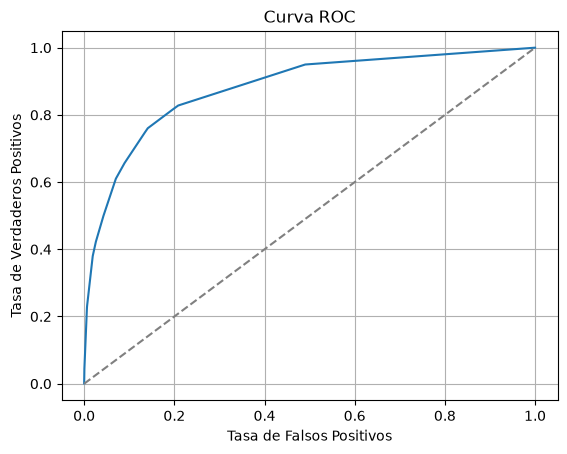

In [14]:
leaf2_df['TPR'] = leaf2_df['TP'] / (leaf2_df['TP'] + leaf2_df['FN'])
leaf2_df['FPR'] = leaf2_df['FP'] / (leaf2_df['FP'] + leaf2_df['TN'])

sns.lineplot(x='FPR', y='TPR', data=leaf2_df)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.grid(True)
plt.show()

# Nota: Es probable que los valores de FPR y TPR esten lejos del [0,0] y [1,1]
# si ese es su caso, debe agregarlos a mano a la tabla

* La línea de identidad indica el comportamiento de un clasificador que no tiene ninguna habilidad para distinguir entre las clases positivas y negativas.
* Es una métrica independiente de la distribución de clases: La curva ROC no depende de la distribución de las clases en los datos (balance de clases), lo que la hace útil en situaciones donde las clases están desbalanceadas.
* Es una evaluación global del modelo: La curva ROC proporciona una visión más completa del rendimiento del modelo.

No todo son rosas, si queremos comparar 2 modelos, mirar curvas puede ser complejo. Por esto mismo, se suele calcular la métrica **AUC** (Area Under the Curve) como un estatístico de la calidad del modelo.

In [17]:
np.trapezoid(leaf2_df['TPR'], leaf2_df['FPR']) # calcula el área de bajo de la curva

np.float64(0.880210223067957)

* AUC = 1: El modelo clasifica perfectamente todas las instancias. Más cerca de 1 se encuentra el indicador, mejor.
* AUC = 0.5: El modelo no tiene capacidad discriminativa; su rendimiento es equivalente a realizar una clasificación aleatoria.
* AUC < 0.5: Indica un rendimiento peor que una clasificación aleatoria (dale vuelta a la clase).
* Más de una curva puede tener la misma AUC, se suele elegir a la más empinada

### Tarea
* Cambie los parámetros del modelo y vea los impactos en cada una de las métricas.
 * ¿Cuál fue el modelo que dió más ganancia económica? ¿El peor?
 * ¿Cuál fue el modelo que dió mayor AUC? ¿El peor?
* Calcule, dibuje y encuentre el punto de corte óptimo para:
 * Accuracy
 * Sensibilidad
 * Especificidad
 * F1-Score

## EDA
### Sumarizando

Empezamos por un pantallazo sobre todas las variables, con una **sumarización**, agregando 2 estadísticos muy importantes que no trae por defecto **Pandas**

* **Número de valores únicos de una variables**: Muchas veces variables categóricas están codificadas en variables numéricas. Este indicador nos ayudará a detectarlas
* **Número de missing values**: Que cantidad de registros tienen valores numéricos y cuales tiene faltantes. El tratamiento (o no) de missings es uno de los temas que navegarán en los **experimentos colectivos**

Navegue la tabla a la par de el **diccionario de datos**. Los alumnos tienen a subestimar el poder de entender el conjunto de datos a la hora de hacer un buen modelo.

In [18]:
desc_stats = data.describe(include='all') # Calcula estadísticas descriptivas básicas
missing_values = data.isnull().sum() # Calcula el número de valores faltantes por columna
unique_values = data.nunique() # Calcula el número de valores distintos por columna

# Combina las estadísticas en un solo DataFrame
summary_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Unique Values': unique_values
})

pd.concat([summary_table.transpose(), desc_stats], axis=0).transpose()


,Missing Values,Unique Values,count,unique,top,freq,mean,std,min,25%,50%,75%,max
numero_de_cliente,0.0,163284.0,163284.0,NaN,NaN,NaN,37665648.152238,15780906.293389,12159854.0,25322583.75,35797950.0,48864749.0,77722076.0
foto_mes,0.0,1.0,163284.0,NaN,NaN,NaN,202104.0,0.0,202104.0,202104.0,202104.0,202104.0,202104.0
active_quarter,0.0,2.0,163284.0,NaN,NaN,NaN,0.986876,0.113808,0.0,1.0,1.0,1.0,1.0
cliente_vip,0.0,2.0,163284.0,NaN,NaN,NaN,0.002609,0.051011,0.0,0.0,0.0,0.0,1.0
internet,0.0,5.0,163284.0,NaN,NaN,NaN,0.06237,0.313295,0.0,0.0,0.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Visa_mconsumototal,21790.0,115641.0,141494.0,NaN,NaN,NaN,21864.234922,40331.363608,-60767.61,2276.36,9822.965,26457.68,2779277.95
Visa_cconsumos,21790.0,132.0,141494.0,NaN,NaN,NaN,8.160565,9.864165,0.0,2.0,5.0,11.0,180.0
Visa_cadelantosefectivo,21790.0,14.0,141494.0,NaN,NaN,NaN,0.008792,0.201397,0.0,0.0,0.0,0.0,16.0
Visa_mpagominimo,7987.0,5726.0,155297.0,NaN,NaN,NaN,6082.537715,18668.150809,0.0,586.5,2252.16,5618.67,2073101.55


### Explorando las variables más importantes del modelo

Vamos a profundizar sobre las variables utilizadas por el modelo. Si las eligió el modelo, seguro nos ayudará a entender un poco más los datos, no?

Para este fin, vamos a obtener la importancia de variable del modelo

In [19]:
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
feature_importances.sort_values('importance', ascending=False)


,feature,importance
107,ctrx_quarter,0.325134
111,Master_status,0.170388
22,mcuentas_saldo,0.140767
33,mprestamos_personales,0.097149
113,Master_Fvencimiento,0.093770
...,...,...
148,Visa_mpagosdolares,0.000000
150,Visa_mconsumototal,0.000000
151,Visa_cconsumos,0.000000
152,Visa_cadelantosefectivo,0.000000


Tomaremos algunas para hacer un doble click

#### ctrx_quarter

**¿Qué significa esta variable?** _Cantidad de movimientos voluntarios en las cuentas bancarias (no tarjeta de crédito) que el cliente realizó en los últimos 90 días._

Cómo se trata de una variable numérica, vamos a graficar la densidad por cada clase:

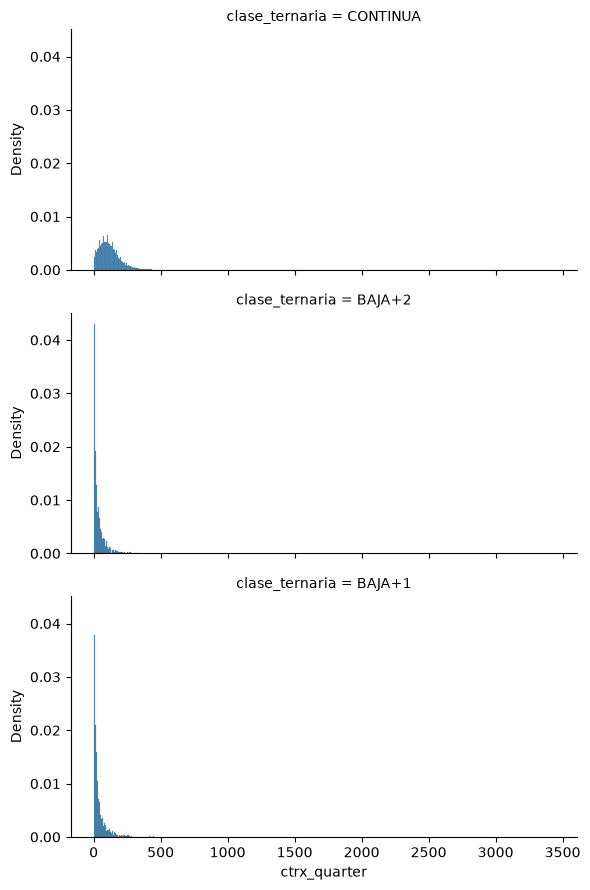

In [20]:
g = sns.FacetGrid(data, row="clase_ternaria", height=3, aspect=2)
g.map(sns.histplot, "ctrx_quarter", stat='density')

* **¿Qué conclusiones saca de los gráficos?**
* **¿Detecta algún patrón en la baja de los clientes?**

#### Visa_status

**¿Qué significa esta variable?** _Valores posibles: {0, 6, 7, 9} -> Indica el estado de la cuenta de la tarjeta de crédito. 0 abierta, 6 en proceso de cierre, 7 en proceso avanzado de cierre, 9 cuenta cerrada. IMPORTANTE: Una cuenta cerrada puede volver a abrirse!_

Esta variable es númerica, pero tiene una baja cardinalidad. Vamos a estudiarla de otra manera

In [21]:
pd.crosstab(data['Visa_status'], data['clase_ternaria'])

clase_ternaria,BAJA+1,BAJA+2,CONTINUA
Visa_status,,,
0.0,635,787,153271
6.0,6,2,6
7.0,19,20,307
9.0,74,23,147


* **¿Qué conclusiones saca de esta tabla?**
* **¿Detecta algún patrón en la baja de los clientes?**

Podemos usar una regla de negocio para `Visa_status > 0`. Veamos algunas métricas de esta misma:

In [22]:
numero_clientes = data.shape[0]
cantidad_baja2 = data[data['clase_ternaria'] == 'BAJA+2'].shape[0]

cantidad_visa_gt_0 = data[data['Visa_status'] > 0].shape[0]
cantidad_visa_gt_0_and_baja2 = data[(data['Visa_status'] > 0) & (data['clase_ternaria'] == 'BAJA+2')].shape[0]

P_baja2 = cantidad_baja2 / numero_clientes

P_visa_status_gt_0_and_baja2 = (cantidad_visa_gt_0_and_baja2 / cantidad_visa_gt_0)

lift = P_visa_status_gt_0_and_baja2 / P_baja2

columnas = ["Métrica", "Valor"]
registros = [
    ("Total de clientes", f"{numero_clientes}"),
    ("P(Visa_status > 0 y BAJA+2)", f"{P_visa_status_gt_0_and_baja2:.6f}"),
    ("P(BAJA+2)", f"{P_baja2:.6f}"),
    ("Lift", f"{lift:.6f}")
]

pd.DataFrame(registros, columns=columnas)

,Métrica,Valor
0,Total de clientes,163284
1,P(Visa_status > 0 y BAJA+2),0.074503
2,P(BAJA+2),0.006976
3,Lift,10.680596


In [23]:
TP = cantidad_visa_gt_0_and_baja2
FN = cantidad_baja2 - TP
FP = cantidad_visa_gt_0 - TP

recall = TP / (TP + FN)

gain = (TP * ganancia_acierto) - (FP * costo_estimulo)

columnas = ["Métrica", "Valor"]
registros = [
    ["TP", f"{TP}"],
    ["FN", f"{FN}"],
    ["FP", f"{FP}"],
    ("Recall", f"{recall:.6f}"),
    ("Ganancia", f"{gain:,.0f} $"),
]
pd.DataFrame(registros, columns=columnas)

,Métrica,Valor
0,TP,45
1,FN,1094
2,FP,559
3,Recall,0.039508
4,Ganancia,"32,890,000 $"


#### mpasivos_margen

**¿Qué significa esta variable?** _Monto total de la ganancia que el banco ha obtenido por el dinero/inversiones que el cliente tiene en el banco._

Esta variable también es númerica. Intente gráficar un diagrama de densidad y verá que no es algo que vaya a funcionar muy bien.

Frente a un escenario así podemos recurrir a los todo poderosos **box-plots**

<Axes: xlabel='clase_ternaria', ylabel='mpasivos_margen'>

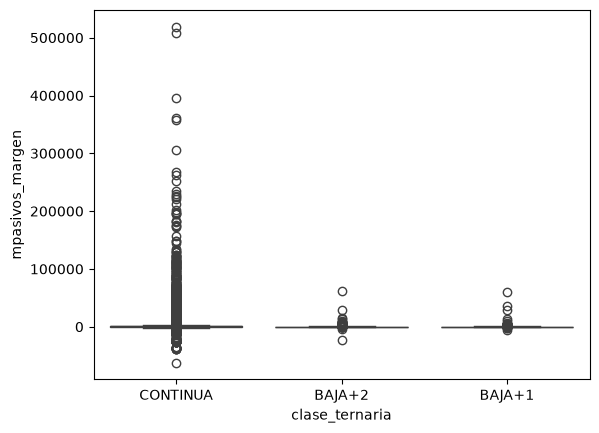

In [24]:
sns.boxplot(x='clase_ternaria', y='mpasivos_margen', data=data)

Ok... esto no es muy ilustrativo.

* **¿Qué son esos círculitos?**

Probemos podar un poco la variable:

<Axes: xlabel='clase_ternaria', ylabel='mpasivos_margen'>

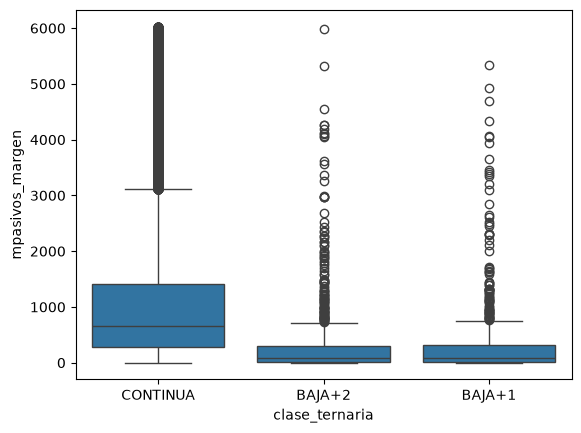

In [25]:
lower_bound = data['mpasivos_margen'].quantile(0.05)
upper_bound = data['mpasivos_margen'].quantile(0.95)

filtered_data = data[(data['mpasivos_margen'] >= lower_bound) & (data['mpasivos_margen'] <= upper_bound)]
sns.boxplot(x='clase_ternaria', y='mpasivos_margen', data=filtered_data)

* **¿Qué paso en el código anterior?**
* **¿Qué interpretación hace sobre el gráfico?**

### Tarea
Esto es solo el comienzo. Tiene que hacer un video a **Miranda** y para eso debe entender bien los datos. Continue con el **EDA**.

* Sume al análisis los periodos descartados
* ¿Se pueden construir features que den más luz a los modelos a detectar las futuras bajas?

Explore junto con su **agente** amigo en busca de nuevos _insights_ y compartalos en Zulip en **#Code>EDA**